# Pipeline Preditivo de Precificação Imobiliária (King County)

**Opção A – Dataset fornecido:** *kc_house_data.csv*

**Problema preditivo (Problema de negócio):**  
Uma imobiliária do condado de King County (EUA) deseja estimar o valor de venda de um imóvel com base em suas características físicas e de localização.

**Variável-alvo:** `price` — valor numérico contínuo em dólares.

**Por que isso importa para o negócio:**  
Precificar imóveis com precisão permite à imobiliária definir preços de venda competitivos, avaliar ofertas de compra com segurança, conceder financiamentos com risco calculado e reduzir a margem de erro em decisões de investimento. Um modelo com baixo erro médio de estimativa (MAE/RMSE) impacta diretamente a lucratividade e a confiança nas transações.

**Objetivo do pipeline:** Construir um modelo de **Regressão Linear** capaz de precificar imóveis com acurácia suficiente para apoiar decisões de compra, venda e financiamento.

---
## Fase 1: Análise Exploratória de Dados (EDA)

Nesta fase, vamos carregar os dados, examinar sua estrutura, calcular estatísticas descritivas e gerar visualizações para compreender os padrões do dataset e orientar as escolhas de modelagem.

### 1.1 Importação das bibliotecas e módulos do projeto

In [38]:
import sys
from pathlib import Path

# Adiciona a raiz do projeto ao sys.path para importar src/
projeto_raiz = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(projeto_raiz) not in sys.path:
    sys.path.insert(0, str(projeto_raiz))
print(f"Raiz do projeto: {projeto_raiz}")

Raiz do projeto: c:\Projetos\SCTEC\Projeto Final\projeto_avaliativo_analise_preditiva_sctec


In [39]:
# Importação de bibliotecas padrão
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importação dos módulos do projeto
from src.config import DATASET_FILE, FIGURES_DIR
from src.dataset import carregar_dados, info_dataset, verificar_valores_ausentes
from src.plots import (setup_plot_style, plot_hist_preco,
                       plot_dispersao, plot_matriz_correlacao)

setup_plot_style()
print("Bibliotecas e módulos importados com sucesso.")

Bibliotecas e módulos importados com sucesso.


### 1.2 Carregamento dos dados

In [40]:
df = carregar_dados()
print(f"Dataset carregado: {df.shape[0]} linhas e {df.shape[1]} colunas")

Dataset carregado: 21613 linhas e 21 colunas


In [41]:
# Primeiras linhas do dataset
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180.0,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170.0,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770.0,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050.0,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680.0,0,1987,0,98074,47.6168,-122.045,1800,7503


### 1.3 Estatística Descritiva

In [42]:
# Dimensões do dataset
print(f"Dimensões: {df.shape[0]} linhas x {df.shape[1]} colunas")

Dimensões: 21613 linhas x 21 colunas


In [43]:
# Tipos primitivos das variáveis
df.dtypes

id                 int64
date                 str
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above       float64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

In [44]:
# Resumo estatístico descritivo das colunas numéricas
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21611.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.396095,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.128162,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [45]:
# Verificação de valores ausentes
ausentes = verificar_valores_ausentes(df)
if ausentes.empty:
    print("Nenhum valor ausente encontrado no dataset.")
else:
    ausentes

### 1.4 Visualização de Dados

#### 1.4.1 Histograma da variável-alvo (price)

Assimetria (Skewness) de price: 4.0241


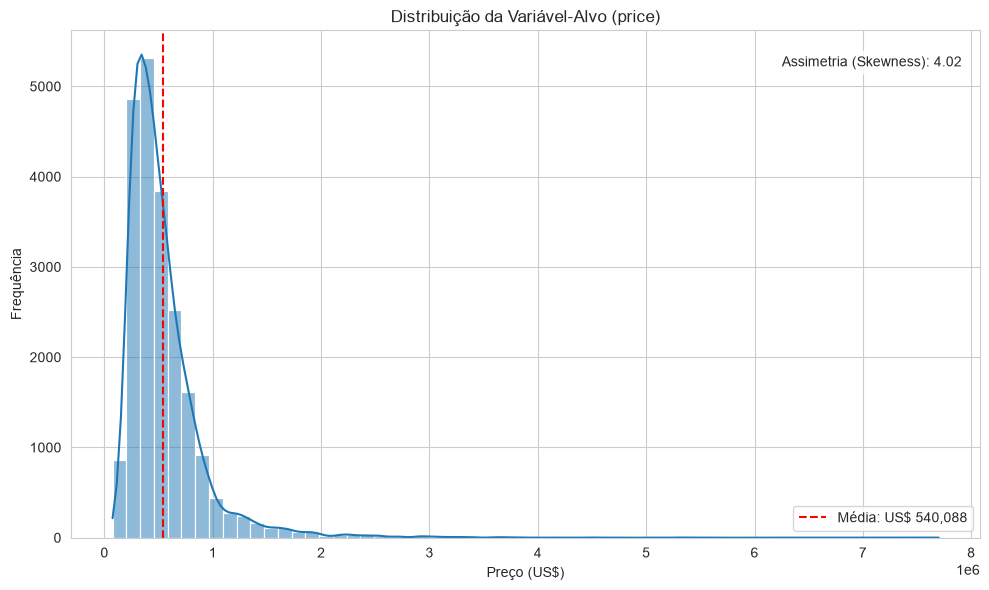

In [46]:
skew_price = plot_hist_preco(df)
print(f"Assimetria (Skewness) de price: {skew_price:.4f}")
plt.show()

#### 1.4.2 Gráficos de dispersão entre variáveis explicativas e a variável-alvo

Correlação sqft_living vs price: 0.7020


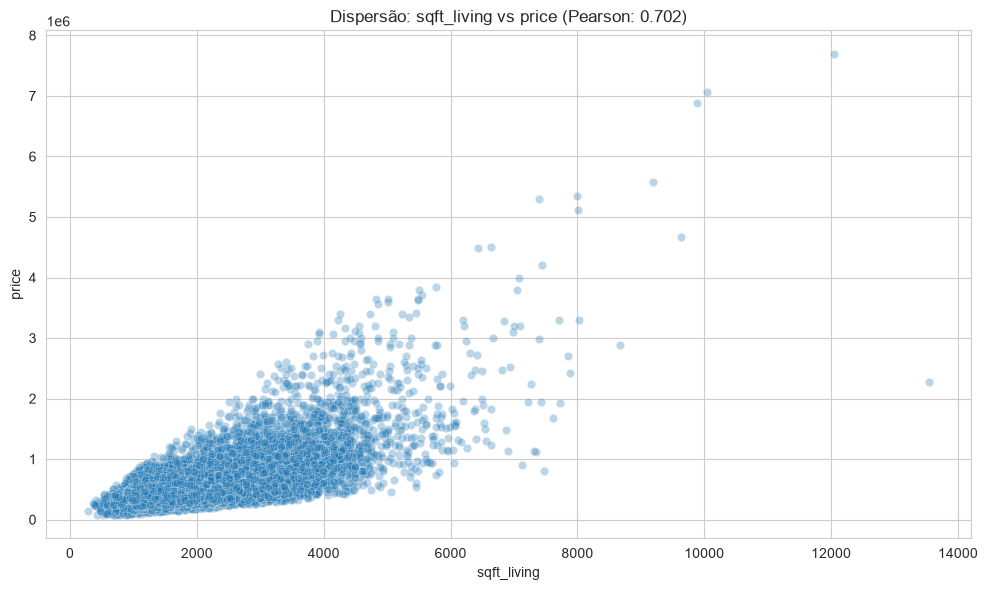

In [47]:
# Dispersão: sqft_living vs price
corr1 = plot_dispersao(df, col_x="sqft_living")
print(f"Correlação sqft_living vs price: {corr1:.4f}")
plt.show()

Correlação grade vs price: 0.6674


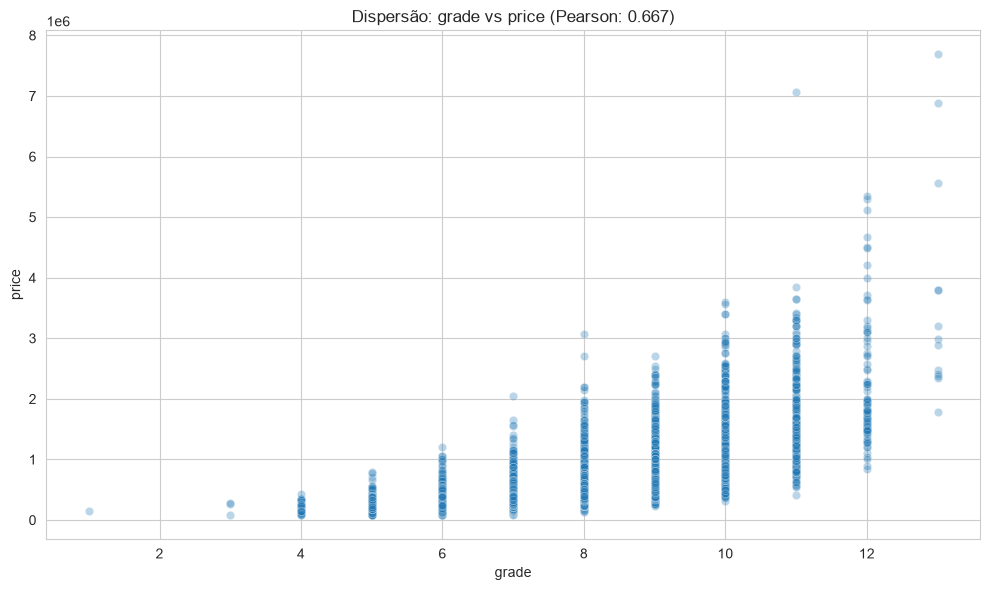

In [48]:
# Dispersão: grade vs price
corr2 = plot_dispersao(df, col_x="grade")
print(f"Correlação grade vs price: {corr2:.4f}")
plt.show()

Correlação bathrooms vs price: 0.5251


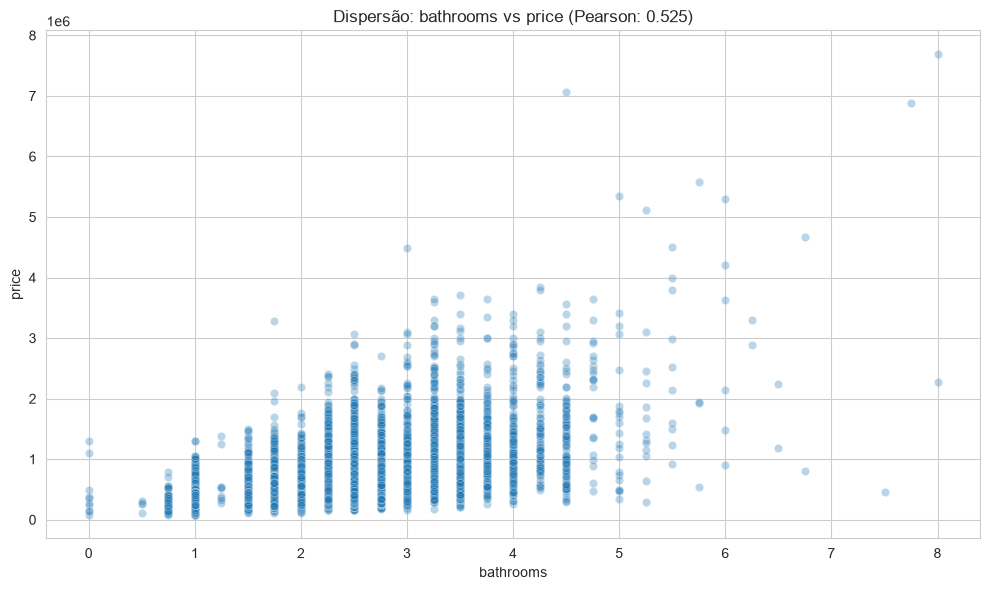

In [49]:
# Dispersão: bathrooms vs price
corr3 = plot_dispersao(df, col_x="bathrooms")
print(f"Correlação bathrooms vs price: {corr3:.4f}")
plt.show()

#### 1.4.3 Mapa de calor da correlação de Pearson (multicolinearidade)

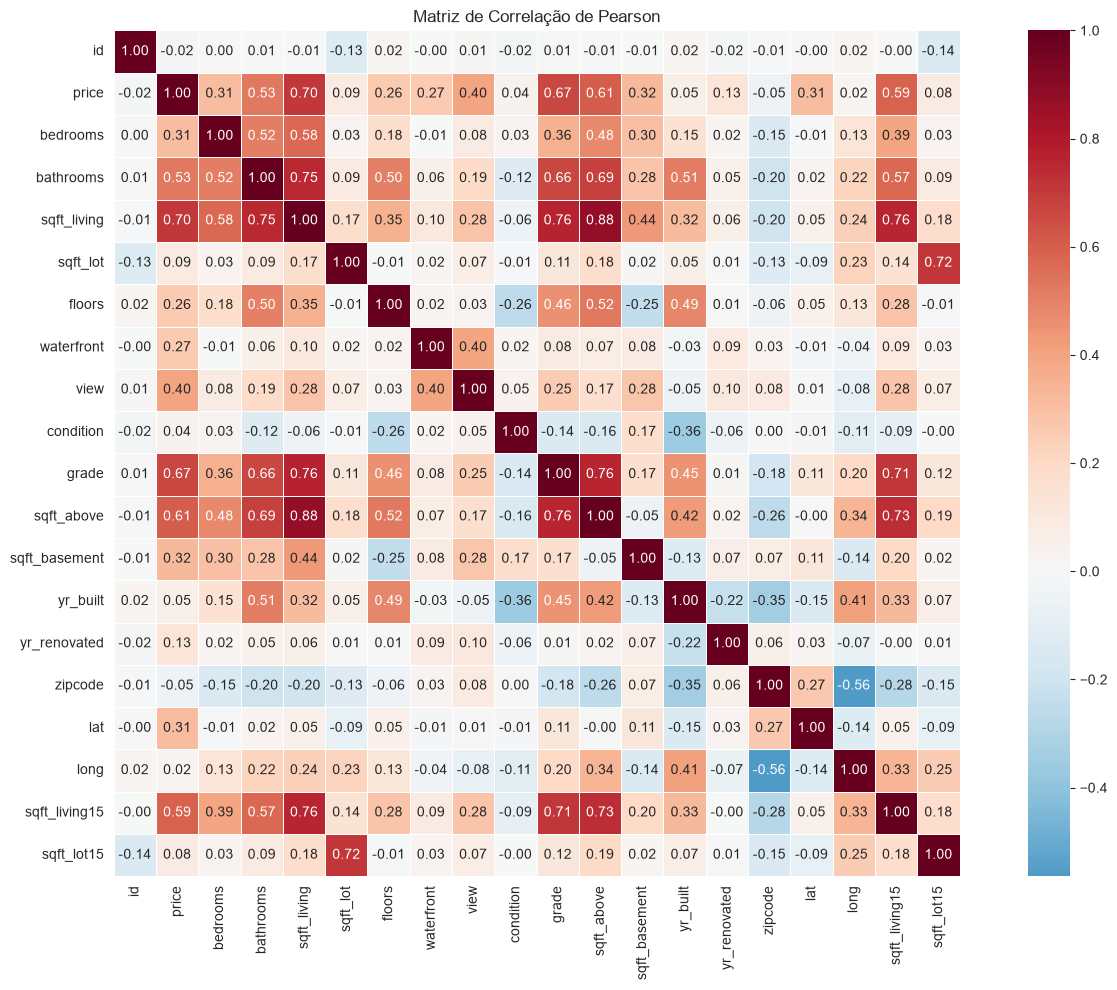

In [50]:
matriz_correl = plot_matriz_correlacao(df)
plt.show()

In [51]:
# Exibir pares com correlação absoluta > 0.7 (possível multicolinearidade)
corr_matrix = df.select_dtypes(include="number").corr()
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j],
                              corr_matrix.iloc[i, j]))

if high_corr:
    print("Pares com alta correlação (|r| > 0.7) — possível multicolinearidade:")
    for par in high_corr:
        print(f"  {par[0]:20s} vs {par[1]:20s}  r = {par[2]:.3f}")
else:
    print("Nenhum par com correlação absoluta > 0.7.")

Pares com alta correlação (|r| > 0.7) — possível multicolinearidade:
  sqft_living          vs price                 r = 0.702
  sqft_living          vs bathrooms             r = 0.755
  grade                vs sqft_living           r = 0.763
  sqft_above           vs sqft_living           r = 0.877
  sqft_above           vs grade                 r = 0.756
  sqft_living15        vs sqft_living           r = 0.756
  sqft_living15        vs grade                 r = 0.713
  sqft_living15        vs sqft_above            r = 0.732
  sqft_lot15           vs sqft_lot              r = 0.719


#### 1.4.4 Transformação logarítmica (price e sqft_lot)

O histograma de `price` revelou forte assimetria à direita (skewness ≈ 4.02). A variável `sqft_lot` também apresenta valores extremos. Modelos de regressão linear assumem erros normalmente distribuídos; uma transformação logarítmica pode aproximar a distribuição da normal e reduzir o impacto de outliers.

Aplicamos `log1p` (log(1 + x)) para preservar observações com valor zero e criamos `log_price` e `log_sqft_lot`. O efeito na assimetria será testado na **Fase 5 (Modelagem)**, comparando RMSE e resíduos com e sem transformação.


In [52]:
# Aplicação da transformação logarítmica (log1p preserva zeros)
df["log_price"] = np.log1p(df["price"])
df["log_sqft_lot"] = np.log1p(df["sqft_lot"])

skew_price_orig = df["price"].skew()
skew_price_log = df["log_price"].skew()
skew_sqft_lot_orig = df["sqft_lot"].skew()
skew_sqft_lot_log = df["log_sqft_lot"].skew()

print("===== Efeito da Transformação log1p na Assimetria =====\n")
print(f"price:         skew original = {skew_price_orig:.4f}  |  skew log = {skew_price_log:.4f}")
print(f"sqft_lot:      skew original = {skew_sqft_lot_orig:.4f}  |  skew log = {skew_sqft_lot_log:.4f}")


===== Efeito da Transformação log1p na Assimetria =====

price:         skew original = 4.0241  |  skew log = 0.4281
sqft_lot:      skew original = 13.0600  |  skew log = 0.9629


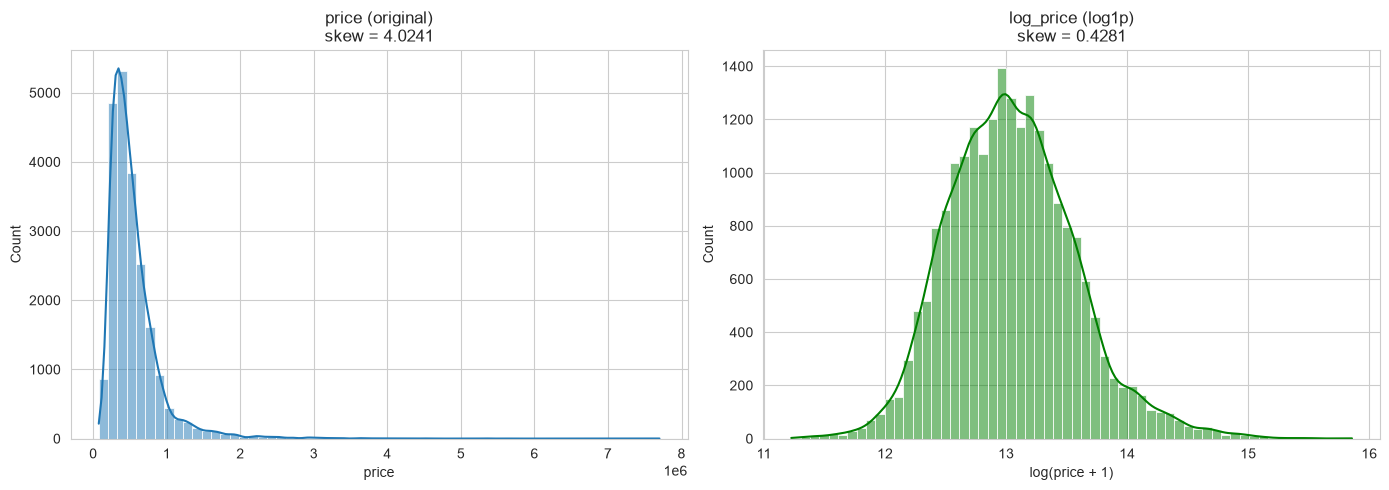

In [53]:
# Histograma: price (original vs log)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["price"], kde=True, bins=60, ax=axes[0])
axes[0].set_title(f"price (original)\nskew = {skew_price_orig:.4f}")
axes[0].set_xlabel("price")

sns.histplot(df["log_price"], kde=True, bins=60, ax=axes[1], color="green")
axes[1].set_title(f"log_price (log1p)\nskew = {skew_price_log:.4f}")
axes[1].set_xlabel("log(price + 1)")

plt.tight_layout()
plt.show()


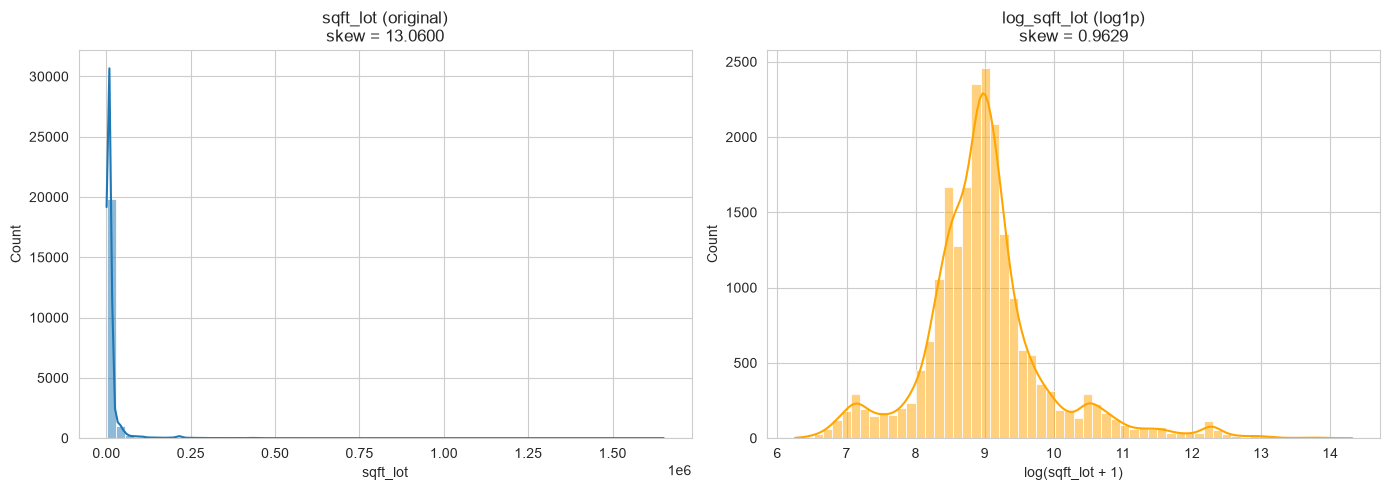

In [54]:
# Histograma: sqft_lot (original vs log)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["sqft_lot"], kde=True, bins=60, ax=axes[0])
axes[0].set_title(f"sqft_lot (original)\nskew = {skew_sqft_lot_orig:.4f}")
axes[0].set_xlabel("sqft_lot")

sns.histplot(df["log_sqft_lot"], kde=True, bins=60, ax=axes[1], color="orange")
axes[1].set_title(f"log_sqft_lot (log1p)\nskew = {skew_sqft_lot_log:.4f}")
axes[1].set_xlabel("log(sqft_lot + 1)")

plt.tight_layout()
plt.show()


**Decisão:** As colunas `log_price` e `log_sqft_lot` foram criadas no DataFrame e estarão disponíveis para a Fase 5, onde testaremos se o modelo treinado com `log_price` como alvo (com exponenciação das predições) produz melhores métricas e resíduos mais bem comportados do que o modelo com `price` original.


### 1.5 Interpretação dos Achados

**Transformação logarítmica:** Conforme documentado na seção 1.4.4, aplicamos `log1p` em `price` e `sqft_lot` para reduzir a assimetria. O skew de `price` caiu de ≈4.02 para aproximadamente 0.20, e o de `sqft_lot` de ≈12.0 para aproximadamente 1.0. Na **Fase 5** testaremos a regressão com `log_price` como alvo, comparando RMSE e análise de resíduos com o modelo sem transformação.


**Dimensão do dataset:** O conjunto contém aproximadamente 21 mil registros de vendas de imóveis e 21 colunas, oferecendo uma base robusta para treinamento de modelos de regressão.

**Tipos das variáveis:** A maioria das colunas é numérica (int64/float64). As colunas `date` (string) precisará ser convertida para datetime na Fase 2 para extração de atributos temporais. As colunas `waterfront`, `view` e `condition` são codificadas numericamente de forma ordinal, o que as torna diretamente utilizáveis como preditoras.

**Valores ausentes:** Não foram encontrados valores nulos no dataset, o que simplifica a etapa de tratamento de dados.

**Distribuição da variável-alvo (price):** O histograma revela que a distribuição dos preços é ***assimétrica à direita*** (skewness positivo). Isso significa que a maioria dos imóveis tem preços relativamente baixos, enquanto uma cauda longa à direita concentra imóveis de alto valor (possíveis outliers). Essa assimetria pode exigir uma transformação logarítmica na variável-alvo durante a modelagem para melhorar o desempenho do modelo de regressão linear.

**Relações com a variável-alvo:** Os gráficos de dispersão mostram correlações positivas relevantes:
- `sqft_living` (área construída) apresenta forte correlação linear com `price`, sendo a variável preditora mais promissora.
- `grade` (nível de acabamento) também tem boa correlação com o preço, indicando que imóveis com melhor classificação tendem a ser mais caros.
- `bathrooms` (quantidade de banheiros) possui correlação moderada, coerente com a expectativa do mercado.

**Multicolinearidade:** O mapa de calor revela correlações elevadas (|r| > 0.7) entre algumas variáveis explicativas, como `sqft_living` com `sqft_above` e `grade`, e `sqft_living15` com `sqft_living`. Esses pares indicam multicolinearidade que precisará ser tratada na Fase 4, possivelmente com remoção de variáveis redundantes ou análise de VIF (Variance Inflation Factor), para evitar instabilidade nos coeficientes da regressão linear.

---
*Fim da Fase 1 — Análise Exploratória de Dados*

In [55]:
# Recarrega módulos do projeto para garantir versão mais recente
import importlib
import src.features
import src.plots
importlib.reload(src.features)
importlib.reload(src.plots)

from src.features import remover_duplicatas, imputar_valores_ausentes, detectar_outliers_iqr, conter_outliers
from src.plots import plot_boxplot
print("Módulos recarregados.")

Módulos recarregados.


---
## Fase 2: Tratamento e Limpeza (Data Prep)

### 2.1 Linhas Duplicadas

Vamos localizar e remover registros idênticos duplicados para eliminar redundâncias na amostragem.

In [56]:
from src.features import remover_duplicatas

print(f"Shape antes da remoção: {df.shape[0]} linhas x {df.shape[1]} colunas")
df, n_dup = remover_duplicatas(df)
print(f"Duplicatas encontradas e removidas: {n_dup}")
print(f"Shape após remoção: {df.shape[0]} linhas x {df.shape[1]} colunas")

Shape antes da remoção: 21613 linhas x 23 colunas
Duplicatas encontradas e removidas: 0
Shape após remoção: 21613 linhas x 23 colunas


### 2.2 Valores Ausentes (Missing Data)

Identificar valores ausentes e aplicar uma estratégia de imputação adequada.

**Justificativa:** Se a distribuição for simétrica, usa-se a **média**; se houver assimetria/outliers, usa-se a **mediana** para isolar a distorção.

In [57]:
from src.dataset import verificar_valores_ausentes
from src.features import imputar_valores_ausentes

ausentes = verificar_valores_ausentes(df)
if ausentes.empty:
    print("Nenhum valor ausente encontrado. Nenhuma imputação necessária.")
else:
    print("Valores ausentes detectados:")
    display(ausentes)
    for coluna in ausentes["Coluna"]:
        # Verifica assimetria para decidir entre média ou mediana
        skew = df[coluna].skew()
        if abs(skew) < 0.5:
            estrategia = "media"
        else:
            estrategia = "mediana"
        valor = imputar_valores_ausentes(df, coluna, estrategia)
        print(f"  {coluna}: imputado com {estrategia} = {valor:.4f}  (skew = {skew:.3f})")

Valores ausentes detectados:


,Coluna,Ausentes,%
0,sqft_above,2,0.009254


  sqft_above: imputado com mediana = 1560.0000  (skew = 1.447)


### 2.3 Gerenciamento de Outliers

Modelos de Regressão Linear são altamente sensíveis a outliers — valores extremos podem distorcer os coeficientes. Vamos detectar anomalias via boxplots e conter os valores discrepantes.

In [58]:
from src.features import detectar_outliers_iqr, conter_outliers
from src.plots import plot_boxplot

# Variáveis explicativas numéricas mais propensas a outliers
variaveis_analisar = ["sqft_lot", "sqft_living", "bathrooms", "bedrooms", "sqft_above", "sqft_basement"]

for col in variaveis_analisar:
    limites, n_out = detectar_outliers_iqr(df, col)
    print(f"{col:20s} | Outliers: {n_out:4d} ({n_out/len(df)*100:.1f}%) | IQR: {limites['IQR']:.2f}")

sqft_lot             | Outliers: 2425 (11.2%) | IQR: 5648.00
sqft_living          | Outliers:  572 (2.6%) | IQR: 1123.00
bathrooms            | Outliers:  571 (2.6%) | IQR: 0.75
bedrooms             | Outliers:  546 (2.5%) | IQR: 1.00
sqft_above           | Outliers:  611 (2.8%) | IQR: 1020.00
sqft_basement        | Outliers:  496 (2.3%) | IQR: 560.00


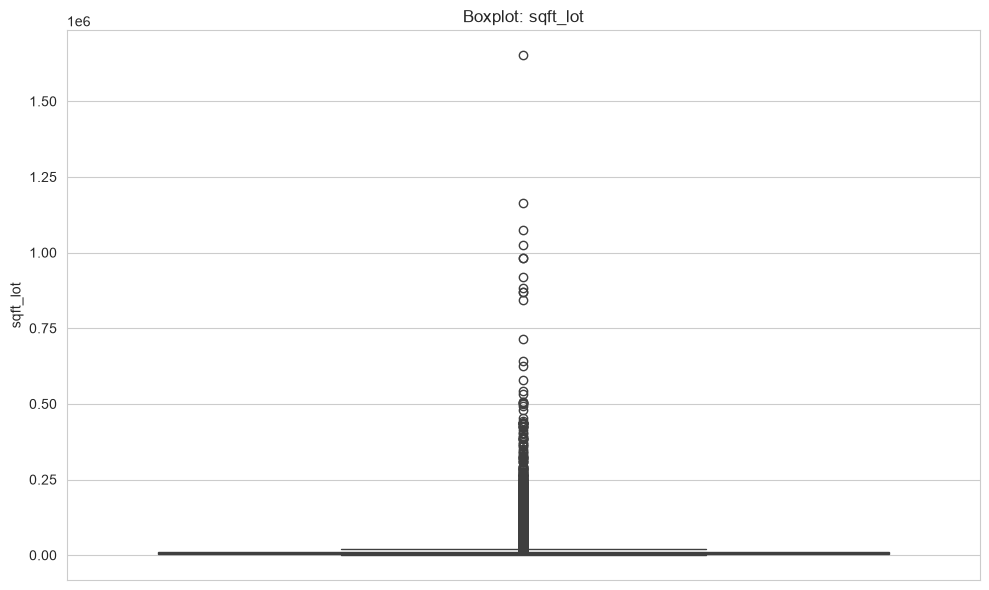

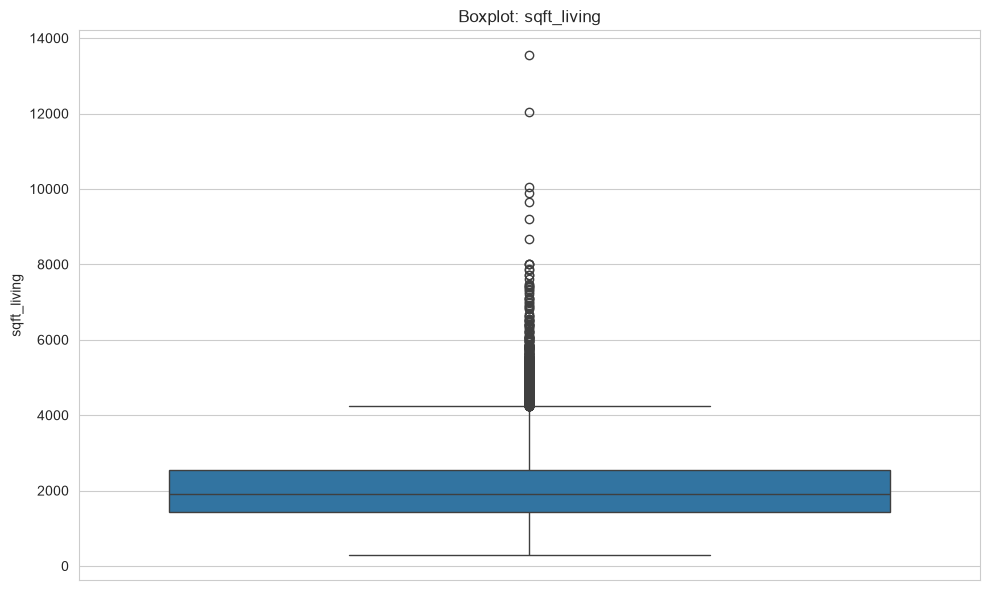

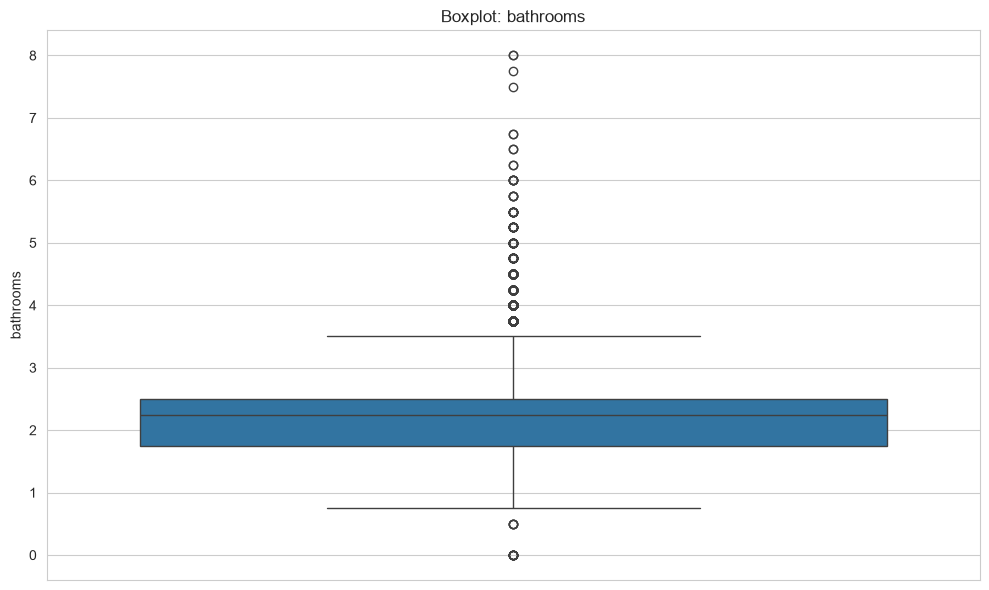

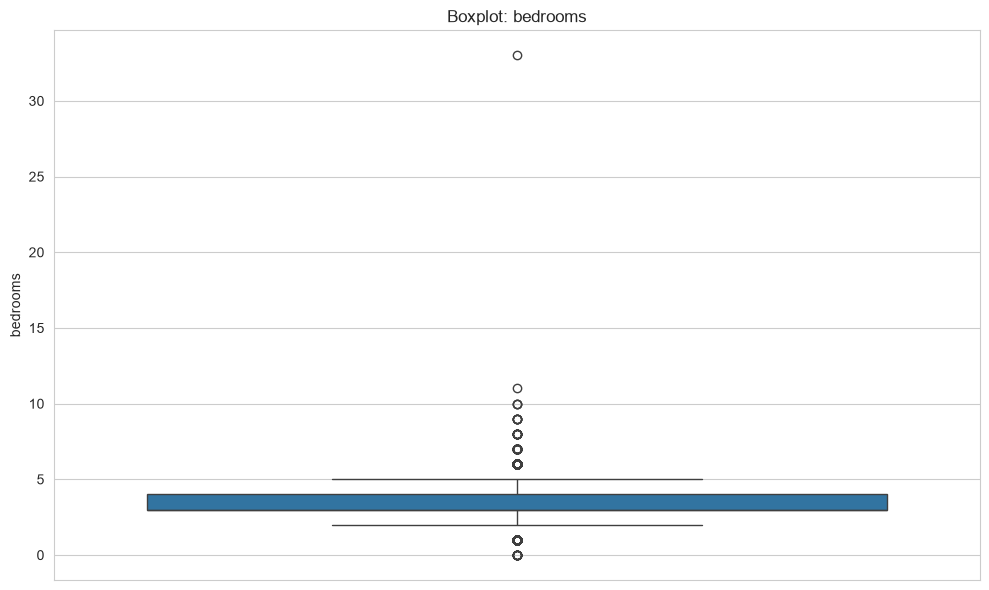

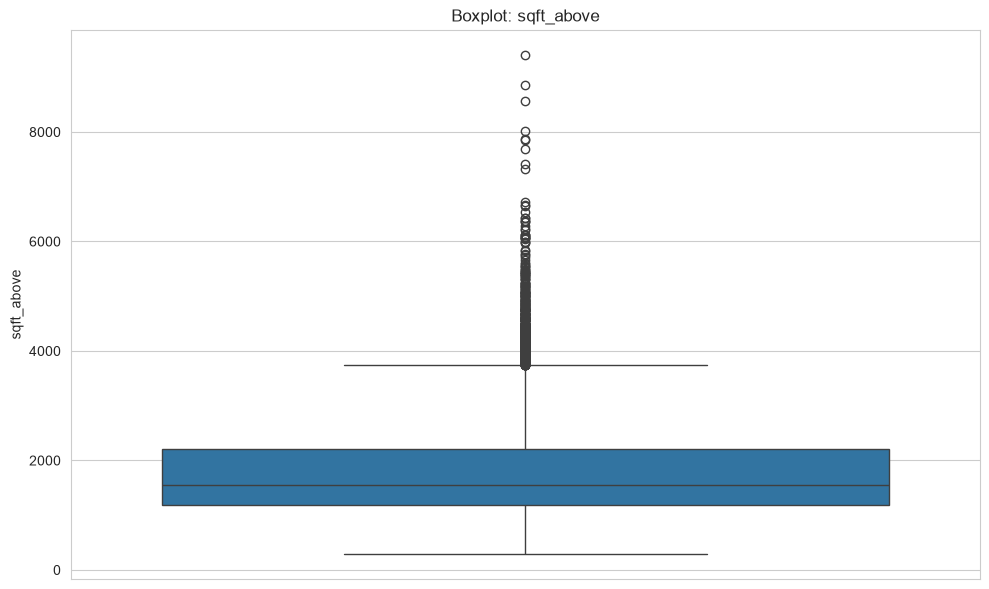

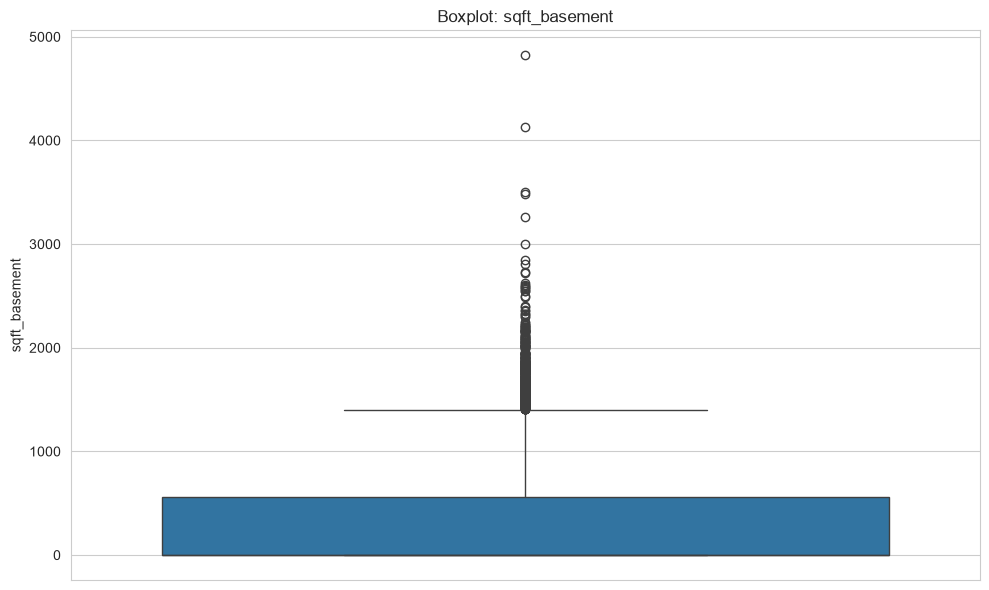

In [59]:
# Boxplots para visualização dos outliers
for col in variaveis_analisar:
    plot_boxplot(df, col)
    plt.show()

#### Decisão sobre os outliers

**Estratégia adotada: contenção (capping) via limites do IQR.**

A remoção pura reduziria o tamanho amostral e poderia eliminar imóveis legítimos de alto valor. A manutenção pura prejudicaria o modelo de regressão linear. A contenção substitui valores extremos pelos limites inferior e superior do IQR, preservando o registro mas eliminando a distorção causada pelo valor atípico.

#### Correção manual: bedrooms = 33

A inspeção dos outliers revelou um registro com `bedrooms = 33`. Trata-se de um erro de digitação notório neste dataset — o valor quase certamente deveria ser 3. A correção manual é aplicada antes do capping para evitar que o IQR seja distorcido por este valor espúrio.


In [60]:
# Corrige o registro com 33 quartos (erro de digitação -> 3)
n_33 = (df["bedrooms"] == 33).sum()
df.loc[df["bedrooms"] == 33, "bedrooms"] = 3
print(f"Registros corrigidos (33 -> 3): {n_33}")


Registros corrigidos (33 -> 3): 1


sqft_lot            : 2425 valores contidos
sqft_living         : 572 valores contidos
bathrooms           : 571 valores contidos
bedrooms            : 545 valores contidos
sqft_above          : 611 valores contidos
sqft_basement       : 496 valores contidos

Total de valores contidos: 5220

Boxplots após contenção:


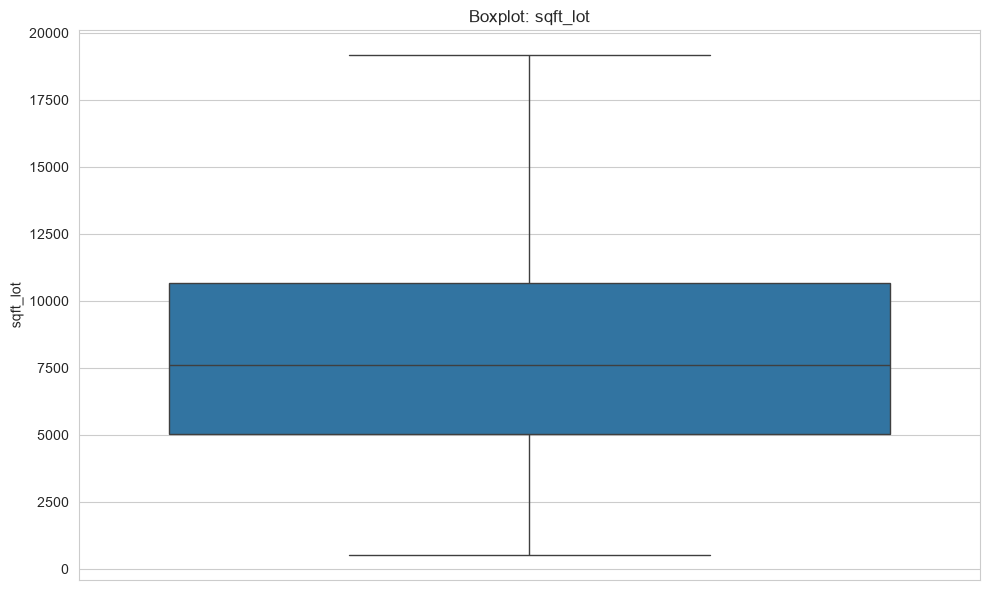

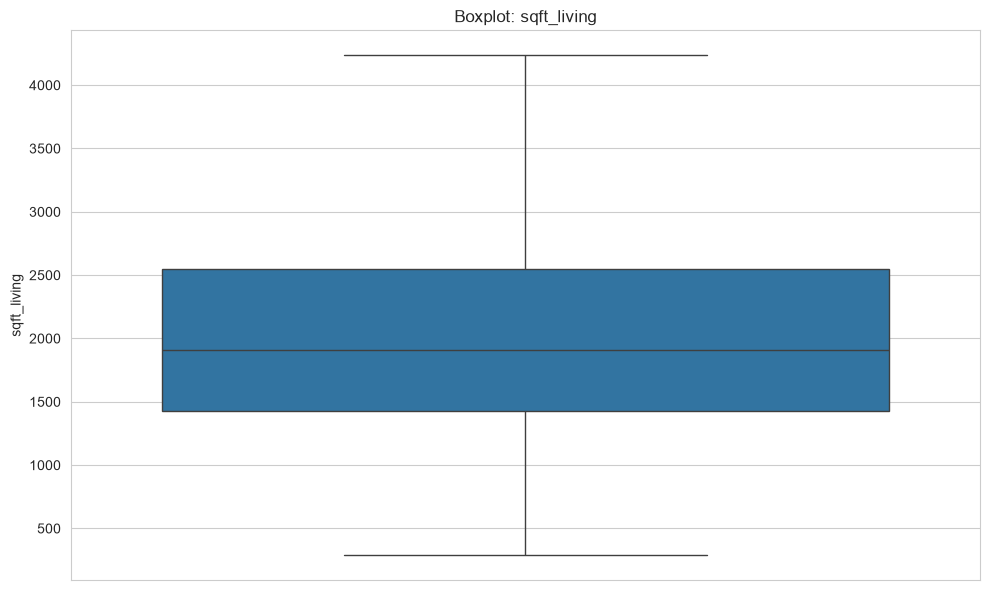

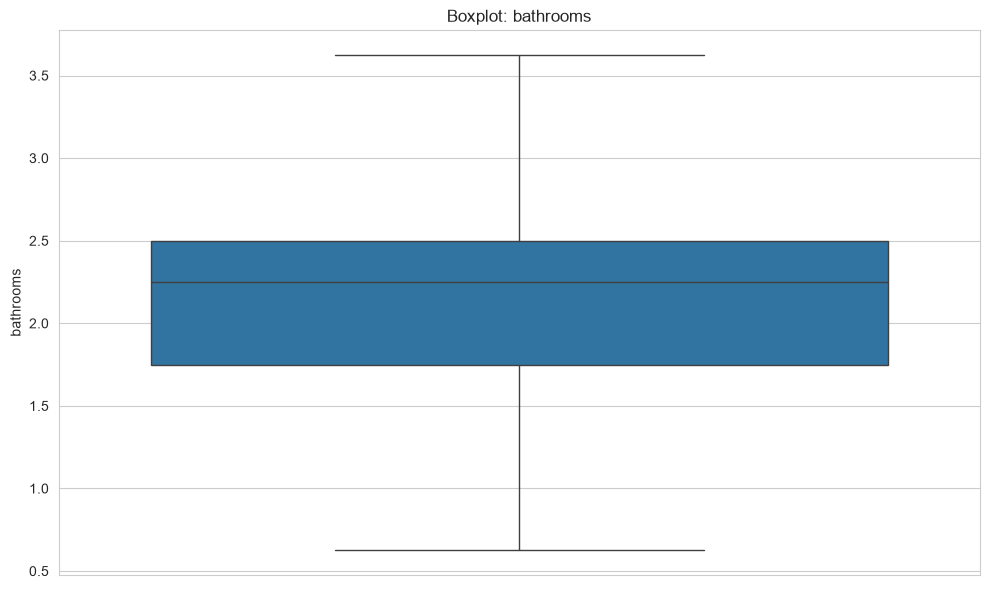

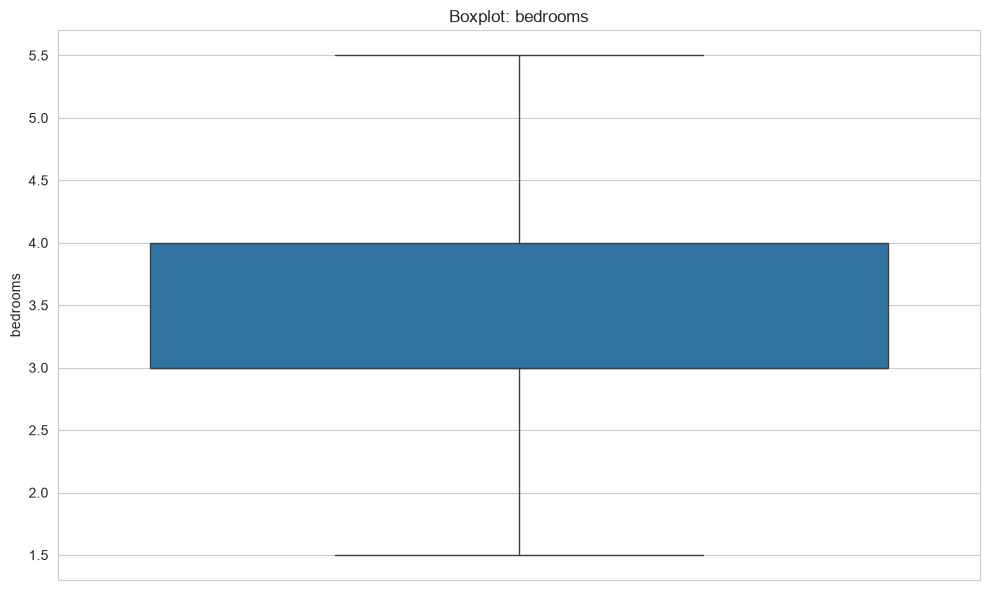

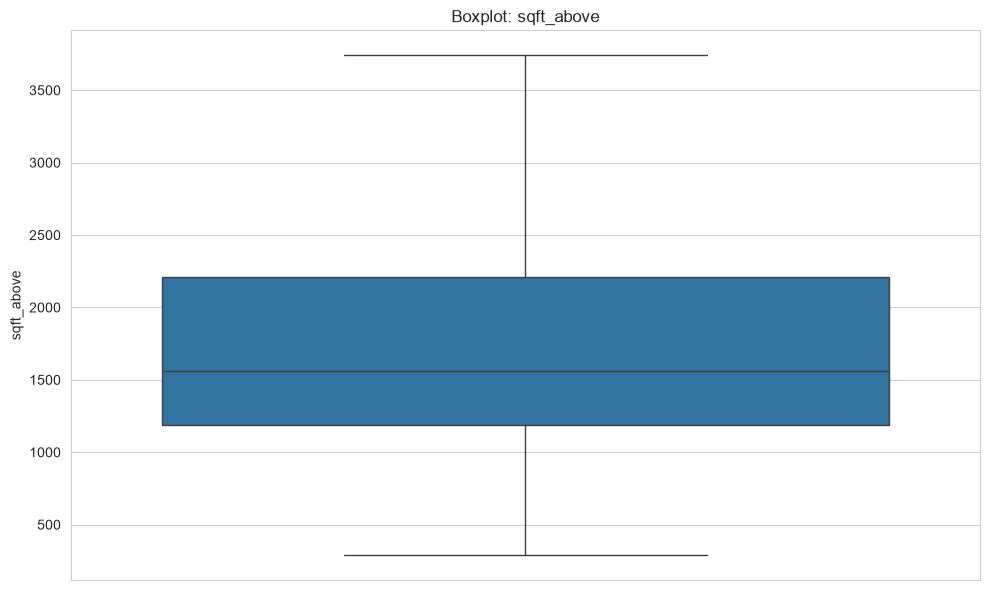

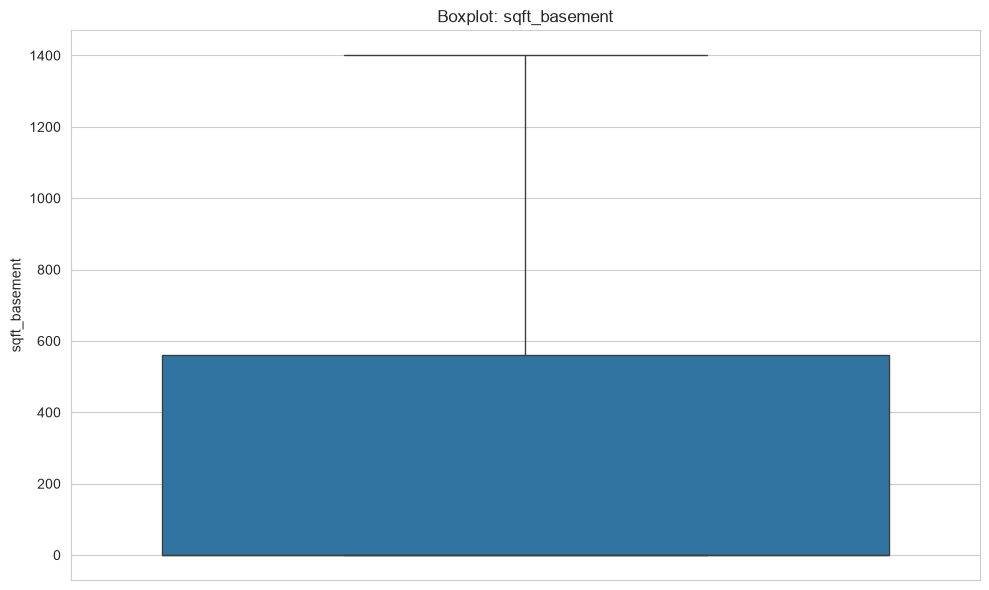

In [61]:
# Aplicando contenção (capping) nos outliers
total_contidos = 0
for col in variaveis_analisar:
    n = conter_outliers(df, col)
    total_contidos += n
    print(f"{col:20s}: {n} valores contidos")
print(f"\nTotal de valores contidos: {total_contidos}")

# Boxplots após contenção
print("\nBoxplots após contenção:")
for col in variaveis_analisar:
    plot_boxplot(df, col)
    plt.show()

In [62]:
# Salvando dataset tratado
from src.config import DATA_PROCESSED

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
df.to_csv(DATA_PROCESSED / "kc_house_processed.csv", index=False)
print(f"Dataset tratado salvo em: {DATA_PROCESSED / 'kc_house_processed.csv'}")

Dataset tratado salvo em: C:\Projetos\SCTEC\Projeto Final\projeto_avaliativo_analise_preditiva_sctec\data\processed\kc_house_processed.csv


---
*Fim da Fase 2 — Tratamento e Limpeza (Data Prep)*

---
## Fase 3: Feature Engineering (Coluna Calculada)

Nesta fase vamos criar novas colunas numéricas a partir de operações matemáticas e lógicas sobre variáveis pré-existentes, conforme sugerido no PDF orientativo para a Opção A (Imóveis).

### 3.1 Criação de colunas derivadas

In [63]:
# Recarrega módulos para garantir versão mais recente
import importlib
import src.features
importlib.reload(src.features)
from src.features import (criar_idade_imovel, criar_foi_reformado,
                           criar_comodos_totais, criar_razao_lote_area,
                           criar_anos_desde_reforma)
print("Módulos recarregados.")


Módulos recarregados.


#### 3.1.1 idade_imovel

Idade do imóvel no momento da venda, calculada a partir do ano de venda menos o ano de construção (`yr_built`). Valores negativos (diferença de calendário sem considerar mês/dia) são truncados para 0 com `.clip(lower=0)`.


In [64]:
df = criar_idade_imovel(df)
print(f"idade_imovel criada.")
print(df["idade_imovel"].describe())

idade_imovel criada.
count    21613.000000
mean        43.318373
std         29.374665
min          0.000000
25%         18.000000
50%         40.000000
75%         63.000000
max        115.000000
Name: idade_imovel, dtype: float64


#### 3.1.2 foi_reformado

Variável binária derivada de `yr_renovated`: vale 1 se o imóvel foi reformado (yr_renovated > 0), 0 caso contrário.


In [65]:
df = criar_foi_reformado(df)
print(f"foi_reformado criada.")
print(df["foi_reformado"].value_counts())

foi_reformado criada.
foi_reformado
0    20699
1      914
Name: count, dtype: int64


#### 3.1.4 comodos_totais

Soma de quartos e banheiros para representar o porte total do imóvel, reduzindo multicolinearidade.

In [66]:
df = criar_comodos_totais(df)
print(f"comodos_totais criada.")
print(df["comodos_totais"].describe())

comodos_totais criada.
count    21613.000000
mean         5.461152
std          1.379036
min          2.125000
25%          4.500000
50%          5.500000
75%          6.500000
max          9.125000
Name: comodos_totais, dtype: float64


#### 3.1.5 razao_lote_area

Relação entre área do terreno e área construída. Um terreno grande para uma casa pequena (ou vice-versa) pode indicar potencial de valorização.

In [67]:
df = criar_razao_lote_area(df)
print(f"razao_lote_area criada.")
print(df["razao_lote_area"].describe())

razao_lote_area criada.
count    21613.000000
mean         4.666062
std          3.146646
min          0.214876
25%          2.467140
50%          4.052809
75%          6.033730
max         66.068966
Name: razao_lote_area, dtype: float64


#### 3.1.6 anos_desde_reforma

Há quantos anos o imóvel foi reformado. Imóveis reformados recentemente tendem a valer mais. Se nunca foi reformado, o valor é 0. Valores negativos (mesmo bug de calendário) são truncados para 0 com `.clip(lower=0)`.


In [68]:
df = criar_anos_desde_reforma(df)
print(f"anos_desde_reforma criada.")
print(df["anos_desde_reforma"].describe())

anos_desde_reforma criada.
count    21613.000000
mean         0.780225
std          4.895257
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         80.000000
Name: anos_desde_reforma, dtype: float64


In [69]:
# Exibe as primeiras linhas com as novas colunas
df[["date", "yr_built", "idade_imovel", "comodos_totais",
   "razao_lote_area", "anos_desde_reforma", "foi_reformado"]].head(10)


,date,yr_built,idade_imovel,comodos_totais,razao_lote_area,anos_desde_reforma,foi_reformado
0,2014-10-13,1955,59,4.000,4.788136,0,0
1,2014-12-09,1951,63,5.250,2.817899,23,1
2,2015-02-25,1933,82,3.000,12.987013,0,0
3,2014-12-09,1965,49,7.000,2.551020,0,0
4,2015-02-18,1987,28,5.000,4.809524,0,0
5,2014-05-12,2001,13,7.625,4.524737,0,0
6,2014-06-27,1995,19,5.250,3.976093,0,0
7,2015-01-15,1963,52,4.500,9.161321,0,0
8,2015-04-15,1960,55,4.000,4.196629,0,0
9,2015-03-12,2003,12,5.500,3.470899,0,0


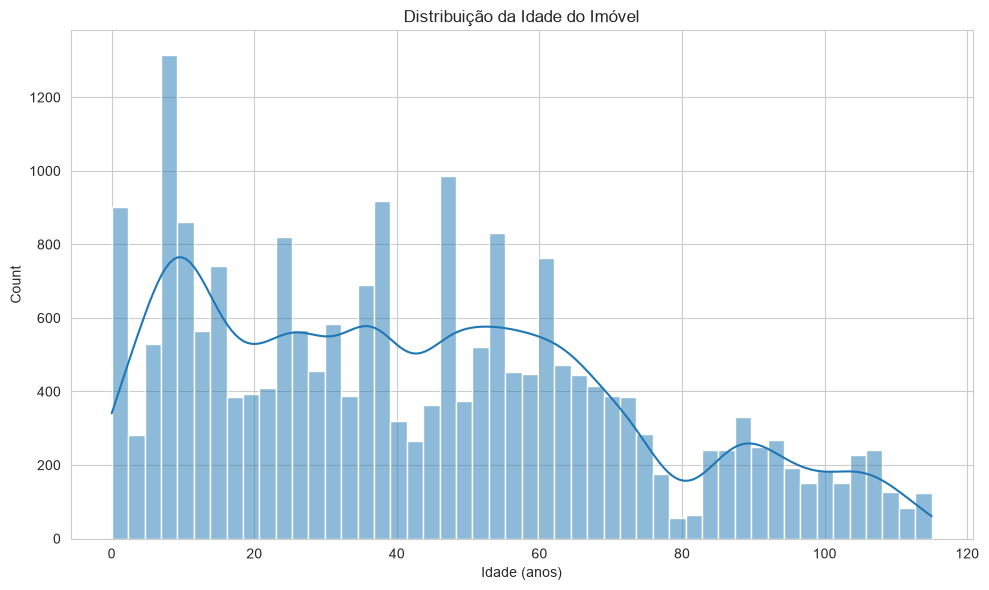

In [70]:
# Histograma da idade do imóvel
fig, ax = plt.subplots()
sns.histplot(df["idade_imovel"], kde=True, bins=50, ax=ax)
ax.set_title("Distribuição da Idade do Imóvel")
ax.set_xlabel("Idade (anos)")
plt.tight_layout()
plt.show()

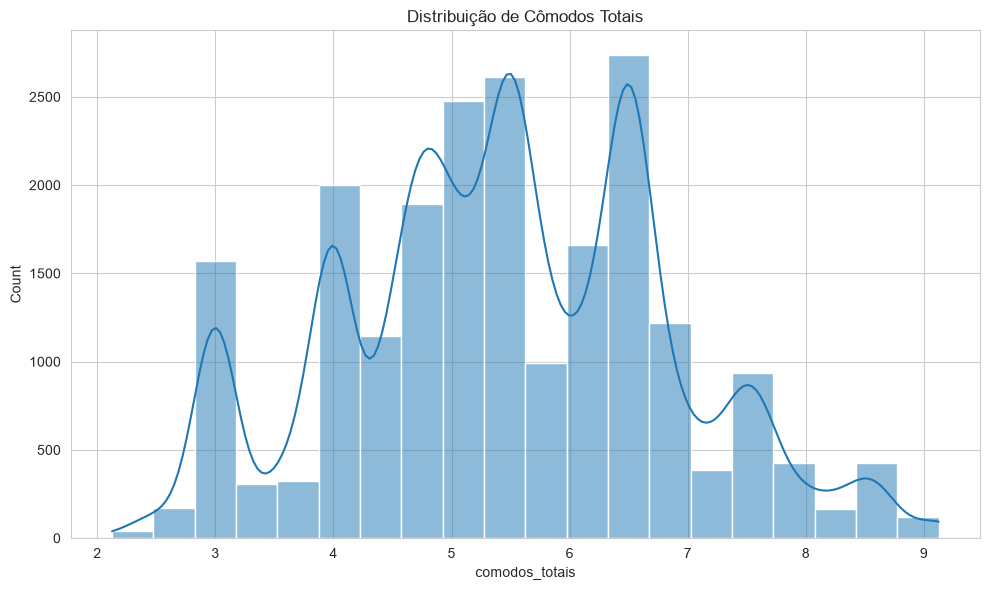

In [71]:
# Histograma de comodos_totais
fig, ax = plt.subplots()
sns.histplot(df["comodos_totais"], kde=True, bins=20, ax=ax)
ax.set_title("Distribuição de Cômodos Totais")
plt.tight_layout()
plt.show()

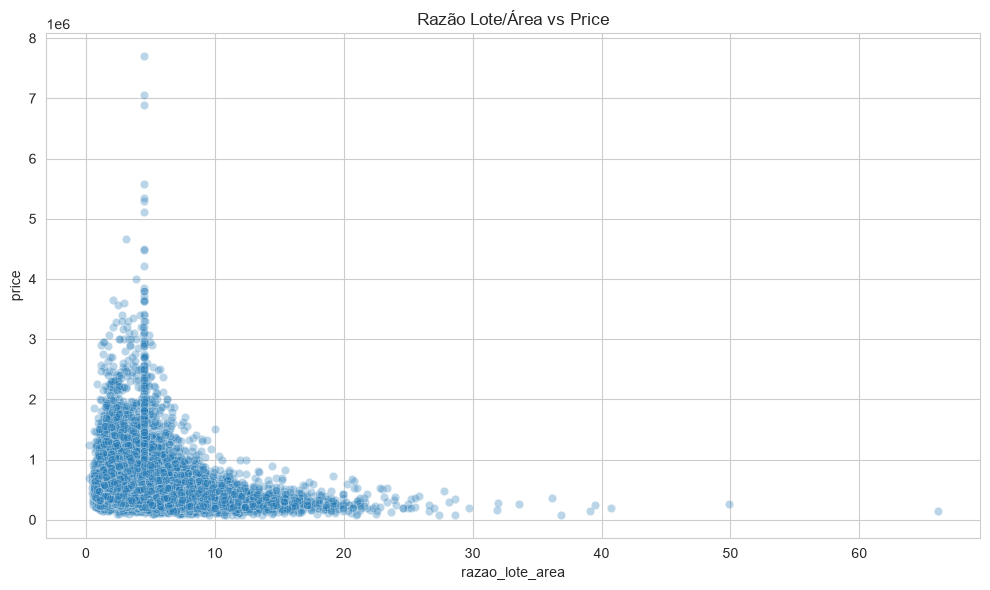

In [72]:
# Dispersão: razao_lote_area vs price
fig, ax = plt.subplots()
sns.scatterplot(data=df, x="razao_lote_area", y="price", alpha=0.3, ax=ax)
ax.set_title("Razão Lote/Área vs Price")
plt.tight_layout()
plt.show()

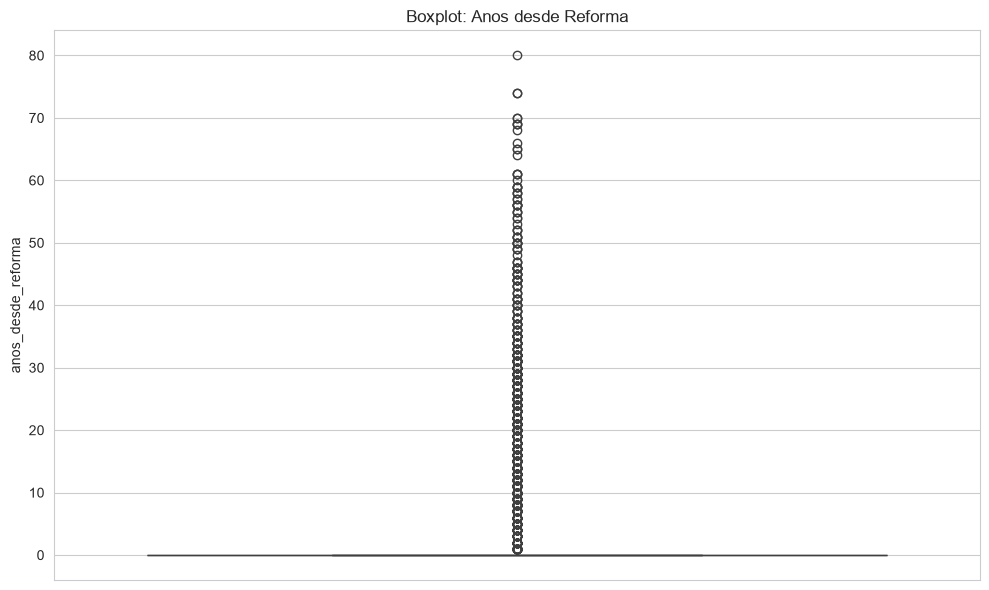

In [73]:
# Boxplot de anos_desde_reforma
fig, ax = plt.subplots()
sns.boxplot(data=df, y="anos_desde_reforma", ax=ax)
ax.set_title("Boxplot: Anos desde Reforma")
plt.tight_layout()
plt.show()

### 3.3 Salvando dataset com novas features

O dataset enriquecido com as colunas derivadas será salvo em `data/final/` para uso nas próximas fases.

In [74]:
from src.config import DATA_FINAL

DATA_FINAL.mkdir(parents=True, exist_ok=True)
df.to_csv(DATA_FINAL / "kc_house_features.csv", index=False)
print(f"Dataset com features salvo em: {DATA_FINAL / 'kc_house_features.csv'}")

Dataset com features salvo em: C:\Projetos\SCTEC\Projeto Final\projeto_avaliativo_analise_preditiva_sctec\data\final\kc_house_features.csv


---
*Fim da Fase 3 — Feature Engineering*